# 03 — Feature Engineering
Build climate risk features from extracted 10-K text including keyword frequency,
disclosure length trends, and a composite climate risk score per company per year.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CLEANED_DIR = Path("../data/cleaned")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEANED_DIR / "extracted_sections.csv")
print(f"Loaded {len(df)} filings")
df.head()

Loaded 546 filings


,ticker,year,item_1a,item_7,item_1a_words,item_7_words
0,AAPL,2017,8,and Analysis of Financial Condition and Result...,1,10
1,AAPL,2018,8,and Analysis of Financial Condition and Result...,1,10
2,AAPL,2019,5,and Analysis of Financial Condition and Result...,1,10
3,AAPL,2020,5,and Analysis of Financial Condition and Result...,1,10
4,AAPL,2021,6,and Analysis of Financial Condition and Result...,1,10


In [2]:
# Climate risk keyword lexicon grouped by category
KEYWORDS = {
    "physical_risk": [
        "flood", "drought", "wildfire", "hurricane", "extreme weather",
        "sea level", "heat stress", "physical risk", "natural disaster",
        "storm", "precipitation", "temperature increase"
    ],
    "transition_risk": [
        "carbon", "emissions", "greenhouse gas", "ghg", "net zero",
        "carbon neutral", "transition risk", "stranded asset", "carbon tax",
        "cap and trade", "renewable energy", "low carbon", "decarbonization"
    ],
    "regulatory": [
        "epa", "paris agreement", "climate regulation", "carbon regulation",
        "tcfd", "sec climate", "climate disclosure", "environmental regulation",
        "climate policy", "climate legislation"
    ],
    "opportunity": [
        "clean energy", "sustainability", "esg", "climate opportunity",
        "green", "sustainable", "climate strategy", "climate initiative"
    ]
}

# Flatten for total count
ALL_KEYWORDS = [kw for group in KEYWORDS.values() for kw in group]
print(f"Total keywords: {len(ALL_KEYWORDS)} across {len(KEYWORDS)} categories")

Total keywords: 43 across 4 categories


In [3]:
def count_keywords(text, keywords):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    text_lower = text.lower()
    return sum(text_lower.count(kw) for kw in keywords)

# Count keywords per category in Item 1A
for category, keywords in KEYWORDS.items():
    df[f"1a_{category}"] = df["item_1a"].apply(
        lambda x: count_keywords(x, keywords)
    )

# Total climate keyword count
df["1a_total_climate_keywords"] = df[[f"1a_{cat}" for cat in KEYWORDS]].sum(axis=1)

# Disclosure length features
df["1a_word_count"] = df["item_1a_words"]
df["7_word_count"] = df["item_7_words"]

# Keyword density (keywords per 1000 words)
df["1a_keyword_density"] = (
    df["1a_total_climate_keywords"] / (df["1a_word_count"] / 1000)
).replace([np.inf, -np.inf], 0).fillna(0)

print("Features created:")
print(df[["ticker", "year", "1a_total_climate_keywords", "1a_keyword_density"]].head(10))

Features created:
  ticker  year  1a_total_climate_keywords  1a_keyword_density
0   AAPL  2017                          0                 0.0
1   AAPL  2018                          0                 0.0
2   AAPL  2019                          0                 0.0
3   AAPL  2020                          0                 0.0
4   AAPL  2021                          0                 0.0
5   AAPL  2022                          0                 0.0
6   AAPL  2023                          0                 0.0
7   AAPL  2024                          0                 0.0
8   AAPL  2025                          0                 0.0
9   AAPL  2015                          0                 0.0


In [4]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [
    "1a_total_climate_keywords",
    "1a_keyword_density", 
    "1a_physical_risk",
    "1a_transition_risk",
    "1a_regulatory",
    "1a_word_count"
]

# Filter to rows with actual content
df_scored = df[df["1a_word_count"] > 100].copy()

# Normalize each feature to 0-1
scaler = MinMaxScaler()
df_scored[feature_cols] = scaler.fit_transform(df_scored[feature_cols])

# Weighted composite score
weights = {
    "1a_total_climate_keywords": 0.30,
    "1a_keyword_density":        0.25,
    "1a_physical_risk":          0.15,
    "1a_transition_risk":        0.15,
    "1a_regulatory":             0.10,
    "1a_word_count":             0.05,
}

df_scored["climate_risk_score"] = sum(
    df_scored[col] * weight for col, weight in weights.items()
)

print(df_scored[["ticker", "year", "climate_risk_score"]].sort_values(
    "climate_risk_score", ascending=False).head(15).to_string(index=False))

ticker  year  climate_risk_score
   CVX  2025            0.822499
   CVX  2023            0.767898
   CVX  2024            0.759808
   CVX  2022            0.687698
   CVX  2017            0.557117
   DUK  2025            0.545226
   CVX  2020            0.507025
   CVX  2018            0.504823
   CVX  2019            0.495754
   DUK  2024            0.493869
   DUK  2023            0.491910
   CVX  2016            0.491624
   CVX  2021            0.490313
   DUK  2022            0.483666
   DUK  2021            0.415698


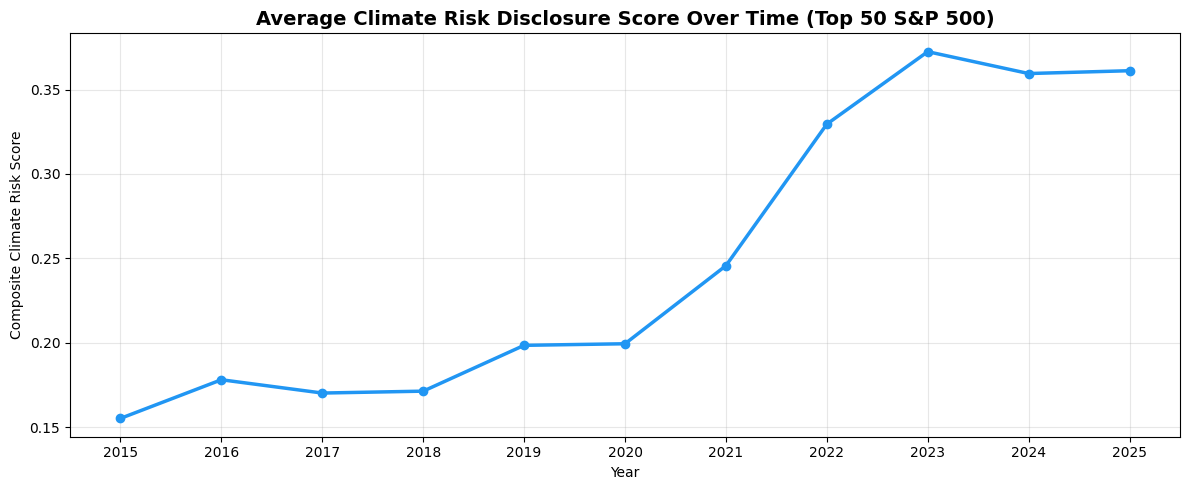

Chart saved.


In [5]:
# Average climate risk score by year
yearly_trend = df_scored.groupby("year")["climate_risk_score"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly_trend["year"], yearly_trend["climate_risk_score"], 
         marker="o", linewidth=2.5, color="#2196F3")
plt.title("Average Climate Risk Disclosure Score Over Time (Top 50 S&P 500)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Composite Climate Risk Score")
plt.xticks(yearly_trend["year"].astype(int))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/climate_score_trend.png", dpi=150)
plt.show()
print("Chart saved.")

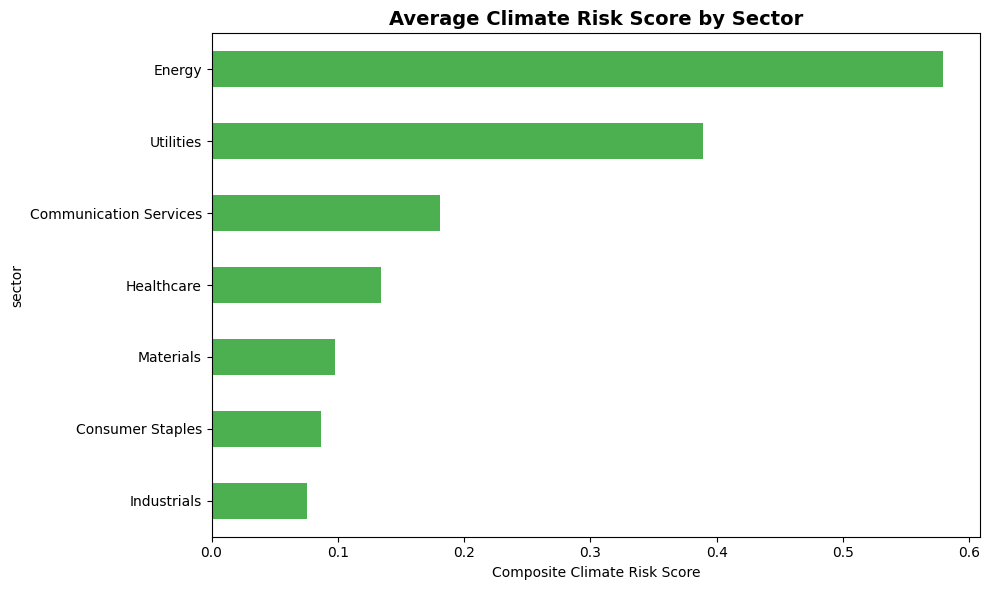

In [6]:
# Load sector mapping from notebook 01
sector_map = {
    "AAPL":"Technology","MSFT":"Technology","NVDA":"Technology",
    "GOOGL":"Technology","META":"Technology","AVGO":"Technology",
    "ORCL":"Technology","CRM":"Technology","AMD":"Technology","ADBE":"Technology",
    "AMZN":"Consumer Discretionary","TSLA":"Consumer Discretionary",
    "HD":"Consumer Discretionary","MCD":"Consumer Discretionary","NKE":"Consumer Discretionary",
    "BRK-B":"Financials","JPM":"Financials","V":"Financials","MA":"Financials",
    "BAC":"Financials","WFC":"Financials","GS":"Financials",
    "LLY":"Healthcare","UNH":"Healthcare","JNJ":"Healthcare",
    "ABBV":"Healthcare","MRK":"Healthcare","TMO":"Healthcare","ABT":"Healthcare",
    "XOM":"Energy","CVX":"Energy",
    "CAT":"Industrials","RTX":"Industrials","HON":"Industrials",
    "GE":"Industrials","UPS":"Industrials",
    "NFLX":"Communication Services","DIS":"Communication Services",
    "T":"Communication Services","VZ":"Communication Services",
    "WMT":"Consumer Staples","PG":"Consumer Staples","KO":"Consumer Staples",
    "PEP":"Consumer Staples","COST":"Consumer Staples",
    "NEE":"Utilities","DUK":"Utilities",
    "LIN":"Materials","APD":"Materials",
}

df_scored["sector"] = df_scored["ticker"].map(sector_map)

sector_scores = df_scored.groupby("sector")["climate_risk_score"].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sector_scores.plot(kind="barh", color="#4CAF50")
plt.title("Average Climate Risk Score by Sector", fontsize=14, fontweight="bold")
plt.xlabel("Composite Climate Risk Score")
plt.tight_layout()
plt.savefig("../outputs/figures/climate_score_by_sector.png", dpi=150)
plt.show()

In [7]:
# Save full scored dataset
output_path = PROCESSED_DIR / "climate_risk_scores.csv"
df_scored.to_csv(output_path, index=False)
print(f"Saved {len(df_scored)} records to {output_path}")
print(f"\nColumns: {list(df_scored.columns)}")

Saved 71 records to ../data/processed/climate_risk_scores.csv

Columns: ['ticker', 'year', 'item_1a', 'item_7', 'item_1a_words', 'item_7_words', '1a_physical_risk', '1a_transition_risk', '1a_regulatory', '1a_opportunity', '1a_total_climate_keywords', '1a_word_count', '7_word_count', '1a_keyword_density', 'climate_risk_score', 'sector']
